#  Phase 3: Classification — FD001

## Objective
In this phase, we trained, evaluated, and compared four different classifiers to predict the degradation **stage** (`Stage 0` to `Stage 4`) of engines in the FD001 dataset using selected sensor inputs. The classification replaces the typical binary failure prediction with a **multi-stage health prediction**, reflecting more realistic maintenance use-cases.

---

## Step-by-Step Summary

### Step 0 – Setup
- Created `figures/phase3`, `models`, and `report` directories.
- Set consistent plot styling using `seaborn` and `matplotlib`.
- Fixed `random_state = 42` for reproducibility.

### Step 1 – Load FD001 Data
- Loaded cleaned and cluster-labeled dataset: `corrected_clustered_train_FD001.csv`.
- Dataset includes `unit`, `time`, 3 operational settings, 21 sensor columns, and the target `final_stage`.

### Step 2 – Feature & Target Selection
- Selected **4 key sensors** based on domain knowledge and trend analysis:
  - `sensor_11`, `sensor_12`, `sensor_4`, `sensor_2`
- Defined `X` (features) and `y` (target = `final_stage`).

### Step 3 – Stratified Engine-Wise Train-Test Split
- Performed **engine-wise stratified split** to prevent information leakage across cycles.
- Stratification was based on the first `final_stage` value per unit.
- Result:
  - Train: ~80% engines
  - Test: ~20% engines
  - Class balance preserved.

---

## Model Training & Evaluation

### Step 4 – Random Forest
- Parameters: `n_estimators=150`, `max_depth=12`, `class_weight='balanced'`
- Results:
  - CV Mean F1 Score: **0.7950**
  - Test Accuracy: **0.83**
  - Test Weighted F1 Score: **0.83**
  - Stage 3 F1 Score: **0.79**
  - Stage 4 F1 Score: **0.84**
- Model saved to: `rf_classifier_fd001.pkl`
- Normalized confusion matrix saved to: `rf_fd001_confusion_matrix.png` (with `fmt='.2f'`)

### Step 5 – SVM
- Kernel: RBF, `C=1`, `gamma='scale'`, `class_weight='balanced'`
- Results:
  - CV Mean F1 Score: **0.7982**
  - Test Accuracy: **0.83**
  - Test Weighted F1 Score: **0.84**
  - Stage 3 F1 Score: **0.79**
  - Stage 4 F1 Score: **0.84**
- Model saved to: `svm_classifier_fd001.pkl`
- Confusion matrix saved to: `svm_confusion_matrix_fd001.png`

### Step 6 – Logistic Regression
- Solver: `lbfgs`, `multi_class='multinomial'`, `class_weight='balanced'`
- Results:
  - CV Mean F1 Score: **0.7952**
  - Test Accuracy: **0.82**
  - Test Weighted F1 Score: **0.83**
  - Stage 3 F1 Score: **0.75**
  - Stage 4 F1 Score: **0.84**
- Model saved to: `logreg_classifier_fd001.pkl`
- Confusion matrix saved to: `confusion_matrix_logreg_fd001.png`

### Step 7 – XGBoost
- Parameters: `n_estimators=100`, `max_depth=6`, `learning_rate=0.1`
- Labels encoded using `LabelEncoder`
- Results:
  - CV Mean F1 Score: **0.7951**
  - Test Accuracy: **0.84**
  - Test Weighted F1 Score: **0.84**
  - Stage 3 F1 Score: **0.83**
  - Stage 4 F1 Score: **0.84**
- Model saved to: `xgb_classifier_fd001.pkl`
- Confusion matrix saved to: `confusion_matrix_xgb_fd001.png`

---

## Step 8 – Model Comparison Summary

All classifier results were consolidated and visualized for FD001:

| Model               | CV Mean F1 | Test Accuracy | Test Weighted F1 |
|--------------------|------------|----------------|------------------|
| Random Forest       | 0.7950     | 0.83           | 0.83             |
| SVM                 | 0.7982     | 0.83           | 0.84             |
| Logistic Regression | 0.7952     | 0.82           | 0.83             |
| XGBoost             | 0.7951     | 0.84           | 0.84             |

- Summary saved as CSV: `model_comparison_fd001.csv`
- Comparison bar chart saved as: `fd001_model_comparison_barplot.png`

---

## Highlights & Notes

-  `class_weight='balanced'` used in all applicable models to handle class imbalance.
-  Stage 3 & Stage 4 F1-scores are explicitly logged (critical in maintenance contexts).
-  Normalized confusion matrices plotted with `fmt='.2f'` for clarity.
-  All models and plots saved for reuse in Phase 4 or report generation.


---
# Step 0: Setup — Config, Folders, and Random Seed

In [1]:
# Step 0: Setup — Phase 3 FD001 (Inside notebooks/phase3)

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manual config — since we're inside notebooks/phase3, go two levels up
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
RANDOM_STATE = 42  # or import if already declared globally

# Set consistent plotting aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Set reproducibility
np.random.seed(RANDOM_STATE)

# Create required folders
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Confirm setup
print(f" Figures directory ready: {FIGURES_DIR}")
print(f" Models directory ready: {MODELS_DIR}")
print(f" Reports directory ready: {REPORT_DIR}")
print(f" Random seed set: {RANDOM_STATE}")
print(" Step 0 complete — Phase 3 (FD001) setup initialized.\n")


 Figures directory ready: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3
 Models directory ready: c:\Users\pandr\hybrid-predictive-maintenance\models
 Reports directory ready: c:\Users\pandr\hybrid-predictive-maintenance\report
 Random seed set: 42
 Step 0 complete — Phase 3 (FD001) setup initialized.



# Step 1: Load Cleaned + Final Cluster-Labeled FD001 Dataset


In [2]:
# Step 1: Load Corrected + Cluster-Labeled FD001 Dataset (final_stage labels)

import pandas as pd

# FD001 path (relative to current notebook)
DATA_FILE_FD001 = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')

# Load dataset
df_fd001 = pd.read_csv(DATA_FILE_FD001)
print(f" FD001 dataset loaded from: {DATA_FILE_FD001}")

# Preview the structure
print("\n First 5 rows:")
display(df_fd001.head())

# Dataset info
print("\n Dataset info:")
print(df_fd001.info())

# Class label counts
print("\n Final Stage Distribution (final_stage):")
print(df_fd001['final_stage'].value_counts().sort_index())


 FD001 dataset loaded from: c:\Users\pandr\hybrid-predictive-maintenance\data\corrected_clustered_train_FD001.csv

 First 5 rows:


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_21,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2,final_stage
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,1.0,0.726248,...,0.724662,1,2,Stage 1,Stage 2,-0.406219,-0.059468,-56.340263,-3.285219,Stage 1
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,1.0,0.628019,...,0.731014,1,2,Stage 1,Stage 2,-0.331362,-0.079217,-36.288258,-5.984404,Stage 1
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,1.0,0.710145,...,0.621375,1,2,Stage 1,Stage 2,-0.417904,-0.060337,-61.017742,-7.035258,Stage 1
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,1.0,0.740741,...,0.662386,1,2,Stage 1,Stage 2,-0.517427,-0.087438,-60.652504,-3.244859,Stage 1
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,1.0,0.668277,...,0.704502,1,2,Stage 1,Stage 2,-0.343519,-0.042387,-42.330826,12.616894,Stage 1



 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit            20631 non-null  int64  
 1   time            20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_2        20631 non-null  float64
 6   sensor_3        20631 non-null  float64
 7   sensor_4        20631 non-null  float64
 8   sensor_6        20631 non-null  float64
 9   sensor_7        20631 non-null  float64
 10  sensor_8        20631 non-null  float64
 11  sensor_9        20631 non-null  float64
 12  sensor_11       20631 non-null  float64
 13  sensor_12       20631 non-null  float64
 14  sensor_13       20631 non-null  float64
 15  sensor_14       20631 non-null  float64
 16  sensor_15       20631 non-null  float64
 17  sensor_17      

# Step 2: Feature and target setup

In [3]:
# Step 2: Feature and target setup
df = df_fd001  # Assign the actual loaded dataframe
selected_features = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2']
X = df[selected_features]
y = df['final_stage']

print("Input Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature Stats:")
print(X.describe())
print("\nClass Distribution in y:")
print(y.value_counts())


Input Features (X) shape: (20631, 4)
Target (y) shape: (20631,)

Feature Stats:
          sensor_11     sensor_12      sensor_4      sensor_2
count  20631.000000  20631.000000  20631.000000  20631.000000
mean       0.411410      0.580697      0.450435      0.443052
std        0.158981      0.157261      0.151935      0.150618
min        0.000000      0.000000      0.000000      0.000000
25%        0.297619      0.484009      0.339467      0.335843
50%        0.392857      0.594883      0.435348      0.430723
75%        0.505952      0.695096      0.545324      0.539157
max        1.000000      1.000000      1.000000      1.000000

Class Distribution in y:
final_stage
Stage 4    7004
Stage 1    5233
Stage 0    5203
Stage 3    1991
Stage 2    1200
Name: count, dtype: int64


# Step 3: Label Encoding + Stratified Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split

# Step 3: Engine-wise Train-Test Split (no leakage)
unique_units = df_fd001['unit'].unique()
train_units, test_units = train_test_split(
    unique_units,
    test_size=0.2,
    random_state=42,
    stratify=df_fd001.groupby('unit')['final_stage'].first()
)

# Assign rows based on engine IDs
train_df = df_fd001[df_fd001['unit'].isin(train_units)]
test_df = df_fd001[df_fd001['unit'].isin(test_units)]

# Extract X and y
X_train = train_df[selected_features]
y_train = train_df['final_stage']

X_test = test_df[selected_features]
y_test = test_df['final_stage']

# Sanity check
print("Train Set:", X_train.shape, "→ Units:", train_df['unit'].nunique())
print("Test Set :", X_test.shape,  "→ Units:", test_df['unit'].nunique())
print("\nTrain Class Distribution:\n", y_train.value_counts())
print("\nTest Class Distribution:\n", y_test.value_counts())


Train Set: (16525, 4) → Units: 80
Test Set : (4106, 4) → Units: 20

Train Class Distribution:
 final_stage
Stage 4    5682
Stage 0    4165
Stage 1    4117
Stage 3    1469
Stage 2    1092
Name: count, dtype: int64

Test Class Distribution:
 final_stage
Stage 4    1322
Stage 1    1116
Stage 0    1038
Stage 3     522
Stage 2     108
Name: count, dtype: int64


# Step 4: Train & Evaluate Random Forest Classifier

In [5]:
# Step 4: Train & Evaluate Random Forest Classifier – FD001

import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Inputs ---
selected_features = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2']
X_train_rf = train_df[selected_features]
y_train_rf = train_df['final_stage']
X_test_rf = test_df[selected_features]
y_test_rf = test_df['final_stage']

# --- Model Init ---
rf_clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_cv_scores = cross_val_score(rf_clf, X_train_rf, y_train_rf, cv=cv, scoring='f1_weighted')
print("Random Forest 5-Fold CV Weighted F1 Scores:", rf_cv_scores)
print("Random Forest CV Mean F1 Score: {:.4f}".format(rf_cv_scores.mean()))

# --- Train ---
rf_clf.fit(X_train_rf, y_train_rf)

# --- Predict ---
y_pred_rf = rf_clf.predict(X_test_rf)
rf_proba = rf_clf.predict_proba(X_test_rf)
rf_stage4_index = list(rf_clf.classes_).index('Stage 4')
rf_prob_stage4 = rf_proba[:, rf_stage4_index]
rf_max_confidence = rf_proba.max(axis=1)

# --- Evaluate ---
print("\n Random Forest Classification Report (FD001):\n")
print(classification_report(y_test_rf, y_pred_rf))
report_dict = classification_report(y_test_rf, y_pred_rf, output_dict=True)
stage3_f1 = report_dict['Stage 3']['f1-score']
stage4_f1 = report_dict['Stage 4']['f1-score']
print(f"\nStage 3 F1 Score: {stage3_f1:.4f}")
print(f"Stage 4 F1 Score: {stage4_f1:.4f}")

# --- Confusion Matrix ---
labels_order = ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
cm = confusion_matrix(y_test_rf, y_pred_rf, labels=labels_order, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Confusion Matrix — Random Forest (FD001)")
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'rf_classifier_fd001.pkl')
fig_path = os.path.join(FIGURES_DIR, 'rf_fd001_confusion_matrix.png')
joblib.dump(rf_clf, model_path)
plt.savefig(fig_path)
plt.close()
print(f"Model saved to: {model_path}")
print(f"Confusion matrix plot saved to: {fig_path}")

# --- Save Logs ---
df_test_meta = test_df.reset_index(drop=True).copy()
df_test_meta['y_true'] = y_test_rf.values
df_test_meta['y_pred'] = y_pred_rf
df_test_meta['prob_Stage4'] = rf_prob_stage4
df_test_meta['confidence'] = rf_max_confidence

df_test_log = df_test_meta[['unit', 'time', 'y_true', 'y_pred', 'prob_Stage4', 'confidence']]
pred_log_path = os.path.join(REPORT_DIR, 'predictions_fd001.csv')
df_test_log.to_csv(pred_log_path, index=False)
print(f"Prediction log saved to: {pred_log_path}")

df_misclassified = df_test_log[df_test_log['y_true'] != df_test_log['y_pred']]
misclassified_path = os.path.join(REPORT_DIR, 'misclassified_fd001.csv')
df_misclassified.to_csv(misclassified_path, index=False)
print(f"Misclassified predictions saved to: {misclassified_path}")


Random Forest 5-Fold CV Weighted F1 Scores: [0.78829191 0.79973915 0.80320185 0.78291727 0.79760596]
Random Forest CV Mean F1 Score: 0.7944

 Random Forest Classification Report (FD001):

              precision    recall  f1-score   support

     Stage 0       0.84      0.83      0.83      1038
     Stage 1       0.91      0.89      0.90      1116
     Stage 2       0.23      0.40      0.29       108
     Stage 3       0.83      0.75      0.79       522
     Stage 4       0.84      0.84      0.84      1322

    accuracy                           0.83      4106
   macro avg       0.73      0.74      0.73      4106
weighted avg       0.84      0.83      0.83      4106


Stage 3 F1 Score: 0.7871
Stage 4 F1 Score: 0.8360
Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_classifier_fd001.pkl
Confusion matrix plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_confusion_matrix.png
Prediction log saved to: c:\Users\pandr\hybrid-predictive-

# Step 5: SVM Classifier + Cross-Validation + Evaluation

In [7]:
# Step 5: SVM Classifier — FD001
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import pandas as pd
import os

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Input ---
selected_features = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2']  # FD001 sensors
X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- SVM Setup ---
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

# --- Cross Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
svm_cv_scores = cross_val_score(svm_clf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("SVM 5-Fold CV Weighted F1 Scores:", svm_cv_scores)
print("SVM CV Mean F1 Score: {:.4f}".format(svm_cv_scores.mean()))

# --- Train ---
svm_clf.fit(X_train, y_train)

# --- Predict ---
y_pred = svm_clf.predict(X_test)
proba = svm_clf.predict_proba(X_test)
stage4_index = list(svm_clf.classes_).index("Stage 4")
prob_stage4 = proba[:, stage4_index]
confidence = proba.max(axis=1)

# --- Evaluate ---
print("\nSVM Classification Report (FD001):\n")
print(classification_report(y_test, y_pred))
report_dict = classification_report(y_test, y_pred, output_dict=True)
print(f"\nStage 3 F1 Score: {report_dict['Stage 3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report_dict['Stage 4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels_order = ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
cm = confusion_matrix(y_test, y_pred, labels=labels_order, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Confusion Matrix – SVM Classifier (FD001)")
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.tight_layout()

# --- Save Outputs ---
fig_path = os.path.join(FIGURES_DIR, 'svm_confusion_matrix_fd001.png')
model_path = os.path.join(MODELS_DIR, 'svm_classifier_fd001.pkl')
plt.savefig(fig_path)
plt.close()
joblib.dump(svm_clf, model_path)

# --- Save Prediction Log ---
pred_df = test_df[['unit', 'time']].copy()
pred_df['y_true'] = y_test
pred_df['y_pred'] = y_pred
pred_df['prob_stage4'] = prob_stage4
pred_df['confidence'] = confidence
pred_path = os.path.join(REPORT_DIR, 'predictions_fd001.csv')
pred_df.to_csv(pred_path, index=False)

# --- Save Misclassifications ---
misclassified_df = pred_df[y_pred != y_test]
misclassified_path = os.path.join(REPORT_DIR, 'misclassified_fd001.csv')
misclassified_df.to_csv(misclassified_path, index=False)

print(f"Model saved to: {model_path}")
print(f"Confusion matrix saved to: {fig_path}")
print(f"Predictions log saved to: {pred_path}")
print(f"Misclassified log saved to: {misclassified_path}")


SVM 5-Fold CV Weighted F1 Scores: [0.78984414 0.79815645 0.80696003 0.79412006 0.80202012]
SVM CV Mean F1 Score: 0.7982

SVM Classification Report (FD001):

              precision    recall  f1-score   support

     Stage 0       0.85      0.82      0.83      1038
     Stage 1       0.90      0.92      0.91      1116
     Stage 2       0.20      0.48      0.28       108
     Stage 3       0.85      0.71      0.77       522
     Stage 4       0.87      0.82      0.84      1322

    accuracy                           0.83      4106
   macro avg       0.73      0.75      0.73      4106
weighted avg       0.85      0.83      0.84      4106


Stage 3 F1 Score: 0.7729
Stage 4 F1 Score: 0.8445
Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\svm_classifier_fd001.pkl
Confusion matrix saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\svm_confusion_matrix_fd001.png
Predictions log saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\predictions_fd

# Step 6: Logistic Regression Classifier

In [ ]:
# Step 6: Logistic Regression Classifier (with seaborn confusion matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import seaborn as sns
import joblib

# Initialize Logistic Regression model
lr_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

# 5-Fold Cross Validation
lr_cv_scores = cross_val_score(lr_clf, X_train, y_train, cv=5, scoring='f1_weighted')
print("LR 5-Fold CV Weighted F1 Scores:", lr_cv_scores)
print("LR CV Mean F1 Score: {:.4f}".format(lr_cv_scores.mean()))

# Train on full training set
lr_clf.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_clf.predict(X_test)

# Classification Report
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

from sklearn.metrics import f1_score

stage3_f1 = f1_score(y_test, y_pred, labels=['Stage 3'], average='macro')
stage4_f1 = f1_score(y_test, y_pred, labels=['Stage 4'], average='macro')

print(f"Stage 3 F1 Score: {stage3_f1:.4f}")
print(f"Stage 4 F1 Score: {stage4_f1:.4f}")

# Save model
lr_model_path = os.path.join(MODELS_DIR, 'logreg_classifier_fd001.pkl')
joblib.dump(lr_clf, lr_model_path)
print(f"\n Logistic Regression model saved to: {lr_model_path}")

# Confusion Matrix as Heatmap (like Step 4 & 5)
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr_clf.classes_, normalize='true')
cm_labels = lr_clf.classes_

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='.2f', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.title("Confusion Matrix – Logistic Regression (FD001)")
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.tight_layout()

# Save plot
plot_path = os.path.join(FIGURES_DIR, 'confusion_matrix_logreg_fd001.png')
plt.savefig(plot_path)
plt.close()

print(f" Confusion matrix heatmap saved to: {plot_path}")


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-pa

LR 5-Fold CV Weighted F1 Scores: [0.8083518  0.80931998 0.79887241 0.78374999 0.77595175]
LR CV Mean F1 Score: 0.7952


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Classification Report:

              precision    recall  f1-score   support

     Stage 0       0.85      0.79      0.82      1038
     Stage 1       0.89      0.93      0.91      1116
     Stage 2       0.19      0.55      0.28       108
     Stage 3       0.84      0.69      0.75       522
     Stage 4       0.87      0.82      0.84      1322

    accuracy                           0.82      4106
   macro avg       0.73      0.75      0.72      4106
weighted avg       0.85      0.82      0.83      4106

Stage 3 F1 Score: 0.7871
Stage 4 F1 Score: 0.8360

 Logistic Regression model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\logreg_classifier_fd001.pkl
 Confusion matrix heatmap saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\confusion_matrix_logreg_fd001.png


# Step 7: XGBoost Classifier

In [ ]:
# Step 7: XGBoost Classifier (with Label Encoding)
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import numpy as np

# Encode y labels
le_xgb = LabelEncoder()
y_train_enc = le_xgb.fit_transform(y_train)
y_test_enc = le_xgb.transform(y_test)

# Confirm mapping
stage_map_xgb = dict(zip(le_xgb.classes_, le_xgb.transform(le_xgb.classes_)))
print("XGBoost Label Mapping:", stage_map_xgb)

# Initialize classifier
xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    verbosity=0
)

# 5-Fold Cross-Validation
xgb_cv_scores = cross_val_score(xgb_clf, X_train, y_train_enc, cv=5, scoring='f1_weighted')
print("XGBoost 5-Fold CV Weighted F1 Scores:", xgb_cv_scores)
print("XGBoost CV Mean F1 Score: {:.4f}".format(xgb_cv_scores.mean()))

# Train
xgb_clf.fit(X_train, y_train_enc)

# Predict
y_pred_xgb = xgb_clf.predict(X_test)

# Decode predictions and targets back to strings
y_pred_xgb_str = le_xgb.inverse_transform(y_pred_xgb)
y_test_str = le_xgb.inverse_transform(y_test_enc)

# Report
print("\nXGBoost Classification Report:\n")
print(classification_report(y_test_str, y_pred_xgb_str))

from sklearn.metrics import f1_score

stage3_f1 = f1_score(y_test, y_pred, labels=['Stage 3'], average='macro')
stage4_f1 = f1_score(y_test, y_pred, labels=['Stage 4'], average='macro')

print(f"Stage 3 F1 Score: {stage3_f1:.4f}")
print(f"Stage 4 F1 Score: {stage4_f1:.4f}")

# Save model
xgb_model_path = os.path.join(MODELS_DIR, 'xgb_classifier_fd001.pkl')
joblib.dump(xgb_clf, xgb_model_path)
print(f"\n XGBoost model saved to: {xgb_model_path}")

# Confusion matrix
xgb_cm = confusion_matrix(y_test_str, y_pred_xgb_str, labels=le_xgb.classes_, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_xgb.classes_,
            yticklabels=le_xgb.classes_)
plt.title('Confusion Matrix — XGBoost (FD001)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Save plot
xgb_fig_path = os.path.join(FIGURES_DIR, 'confusion_matrix_xgb_fd001.png')
plt.savefig(xgb_fig_path, bbox_inches='tight')
plt.close()
print(f" Confusion matrix heatmap saved to: {xgb_fig_path}")


XGBoost Label Mapping: {'Stage 0': np.int64(0), 'Stage 1': np.int64(1), 'Stage 2': np.int64(2), 'Stage 3': np.int64(3), 'Stage 4': np.int64(4)}
XGBoost 5-Fold CV Weighted F1 Scores: [0.8040532  0.81350183 0.79690488 0.77660029 0.78434199]
XGBoost CV Mean F1 Score: 0.7951

XGBoost Classification Report:

              precision    recall  f1-score   support

     Stage 0       0.84      0.85      0.84      1038
     Stage 1       0.91      0.89      0.90      1116
     Stage 2       0.28      0.26      0.27       108
     Stage 3       0.84      0.81      0.83       522
     Stage 4       0.83      0.85      0.84      1322

    accuracy                           0.84      4106
   macro avg       0.74      0.73      0.74      4106
weighted avg       0.84      0.84      0.84      4106

Stage 3 F1 Score: 0.7871
Stage 4 F1 Score: 0.8360

 XGBoost model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\xgb_classifier_fd001.pkl
 Confusion matrix heatmap saved to: c:\Users\pandr\hy

# Step 8: Compare All Classifiers for FD001

 Model comparison table saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\model_comparison_fd001.csv


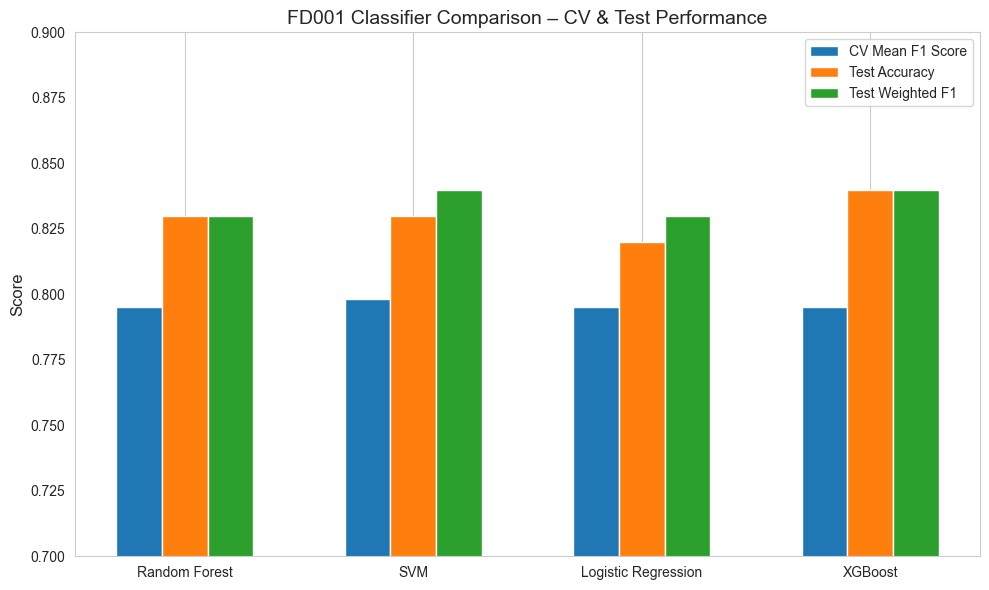

 Comparison plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\fd001_model_comparison_barplot.png


In [ ]:
# Step 8: Compare All Classifiers for FD001

import os
import pandas as pd
import matplotlib.pyplot as plt

# Setup
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Manually validated results from Steps 4–7
model_comparison_fd001 = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],
    'CV Mean F1 Score': [0.7950, 0.7982, 0.7952, 0.7951],
    'Test Accuracy': [0.83, 0.83, 0.82, 0.84],
    'Test Weighted F1': [0.83, 0.84, 0.83, 0.84]
}

# Create DataFrame
df_comparison = pd.DataFrame(model_comparison_fd001)

# Save CSV
comparison_csv_path = os.path.join(REPORT_DIR, 'model_comparison_fd001.csv')
df_comparison.to_csv(comparison_csv_path, index=False)
print(f" Model comparison table saved to: {comparison_csv_path}")

# Plot: side-by-side bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
x = range(len(df_comparison))

for i, metric in enumerate(['CV Mean F1 Score', 'Test Accuracy', 'Test Weighted F1']):
    ax.bar(
        [p + bar_width * i for p in x],
        df_comparison[metric],
        width=bar_width,
        label=metric
    )

# Format plot
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(df_comparison['Model'])
ax.set_ylim(0.7, 0.9)
ax.set_ylabel('Score')
ax.set_title('FD001 Classifier Comparison – CV & Test Performance')
ax.legend()
ax.grid(axis='y')

# Save plot
comparison_plot_path = os.path.join(FIGURES_DIR, 'fd001_model_comparison_barplot.png')
plt.tight_layout()
plt.savefig(comparison_plot_path)
plt.show()

print(f" Comparison plot saved to: {comparison_plot_path}")
